In [ ]:
from DynamicModel import DynamicModel
from mod_solver import Solver
import logging
import numpy as np
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
def find_closest_to_half(arr):
    target_value = 0.5
    # Calculate the absolute differences between each element and the target value
    differences = np.abs(arr - target_value)
    # Find the index of the smallest difference
    index_of_closest = np.argmin(differences)
    return index_of_closest

math_vars = {
    'rho': 1000,
    'visc': 0.001,
    'dia_inlet_Value': 0.017,  # Specific heat capacity in J/(kg*K)
    'initial_static_temperature_air': 368.15,  # Density in kg/m^3
    'initial_static_temperature_water': 353.15,  # Liquid temperature in K
    'inlet_del_t': 10,  # Melting temperature in K
    'inlet_T': 80+273.15,  # Enthalpy of melting in J/kg
    'inlet_v_avg': 0.065,
    'q': 0.65,
    'grev': 0.4,
    'timestep': 0.001,
}

name_vars = {
    'x_dat': "X (m)",
    'y_dat': "Y (m)",
    'mass_check': "Report: mass conservation check (kg/s)",
    'mass_err_air': "Report: mass_conservation_error_air (kg)",
    'pres_1': "Report: probe1_pressure (Pa)",
    'temp_1': "Report: probe1_temperature (K)",
    'pres_2': "Report: probe2_pressure (Pa)",
    'temp_2': "Report: probe2_temperature (K)",
    'pres_3': "Report: probe3_pressure (Pa)",
    'temp_3': "Report: probe3_temperature (K)",
    'pres_4': "Report: probe4_pressure (Pa)",
    'temp_4': "Report: probe4_temperature (K)",
    'water_level': "Report: water level (m)",
    "vof_water": "Volume Fraction of water",
    'time': "Time (s)",
    'velocity_j': "Velocity[j] (m/s)",
}

model = DynamicModel(math_vars)
model.set_nondim_consts(
    ref_l = 'dia_inlet_Value',
    temp_u = 'inlet_v_avg',
    
    ref_rho = 'rho',
    ref_visc = 'visc',
    ref_g = 'grev',
    ref_u = lambda temp_u, ref_l, ref_g: temp_u*temp_u/np.sqrt(ref_g*ref_l), #can remove the grev bit
    ref_t = lambda ref_u, ref_l, ref_g: ref_l/ref_u,
    reynolds = lambda ref_l, ref_rho, ref_u, ref_visc: ref_rho*ref_l*ref_u/ref_visc,
    froude = lambda ref_u, ref_g, ref_l: ref_u*ref_u/(np.sqrt(ref_g*ref_l)),

)

In [ ]:
dir_list = [
    r'D:\thesis\HARD_DATA\subprob1\higher_h',
    r'D:\thesis\HARD_DATA\subprob1\high_h',
    r'D:\thesis\HARD_DATA\subprob1\mid2_h',
    r'D:\thesis\HARD_DATA\subprob1\low2_h',
]
name = 'middle_data_DataTable_'
name_append = '.csv'
h_val = [4, 8, 16, 32]
v_final = [-6.374194e-03, -8.974616e-03, -9.939037e-03,-5.842421e-03]
v_point = [1.973807e-02, 8.168320e-03, 1.430096e-02, 1.364445e-02]
v_mag = [2.007833e-02, 9.147956e-03, 1.462443e-02, 1.372741e-02]
temps = [3.531480e+02, 3.531484e+02, 3.531491e+02, 3.531472e+02]
void_frac = [8.076828e-03, 8.102482e-03, 8.076514e-03, 8.076279e-03]
h_data = []
for idx, path in enumerate(dir_list):
    model.load_solution_data(
                            dir=path,
                            name=name,
                            name_append=name_append,
                            name_vars=name_vars,
                            timestep_from_file= False,
                            sort_by = "y_dat",
                            update_params=False)
    water_level = []
    time_data = []
    pressure_probes = {}
    temperature_probes = {}
    mass_check = []
    mass_err = []
    velocity_data = []
    y_data = []
    void = []
    for data in model.solution_data:
        water_level.append(np.round(np.mean(data['water_level']), decimals=5))
        time_data.append(np.round(np.mean(data['time']), decimals=2))
        mass_check.append(np.round(np.mean(data['mass_check']), decimals=5))
        mass_err.append(np.round(np.mean(data['mass_err_air']), decimals=5))
        velocity_data.append(data['velocity_j'])
        y_data.append(data['y_dat'])
        
        pressure_probes = {
            'p1': np.round(np.mean(data['pres_1']), decimals=5),
            'p2': np.round(np.mean(data['pres_2']), decimals=5),
            'p3': np.round(np.mean(data['pres_3']), decimals=5),
            'p4': np.round(np.mean(data['pres_4']), decimals=5)
        }
        temperature_probes = {
            't1': np.round(np.mean(data['temp_1']), decimals=5),
            't2': np.round(np.mean(data['temp_2']), decimals=5),
            't3': np.round(np.mean(data['temp_3']), decimals=5),
            't4': np.round(np.mean(data['temp_4']), decimals=5)
        }
    cur_h_data = {}
    cur_h_data = {
        'name': h_val[idx],
        'time_dat': time_data,
        'water_level': water_level,
        'mass_check': mass_check,
        'mass_err': mass_err,
        'pressure_data': pressure_probes,
        'temperature-data': temperature_probes,
        'v_conv': v_final[idx],
        'velocity': velocity_data,
        'y_data': y_data
    }
    h_data.append(cur_h_data)

h_data_ref = {
    'ref_time': h_data[-1]['time_dat'][-1],
    'ref_water_level':  h_data[-1]['water_level'][-1],
    'ref_v': v_final[-1]
}

def calc_errs(f):
    rates = []
    for i in range(len(f) - 2):
        rate = ((f[i+2] - f[i+1]))/((f[i+1] - f[i]))
        print(rate)
        rates.append(rate)
    return rates

f1 = []
f2 = []
f3 = []
f4 = []
f5 = []
size_arr = []
for idx, h in enumerate(h_data):
    print(h_data[idx]['water_level'][-1])
    f1.append(h_data[idx]['water_level'][-1])
    f2.append(v_point[idx])
    f3.append(v_mag[idx])
    f4.append(temps[idx])
    f5.append(void_frac[idx])

import numpy as np
from scipy.interpolate import interp1d
def interpolate_velocities_robust(h1_ydata, h2_ydata, h2_velocity):
    # Ensure arrays are numpy arrays
    h1_ydata = np.asarray(h1_ydata)
    h2_ydata = np.asarray(h2_ydata)
    h2_velocity = np.asarray(h2_velocity)
    
    # Check array lengths match
    assert len(h2_ydata) == len(h2_velocity), "h2 arrays must have same length"
    
    # Sort h2 data if not already sorted (required for interpolation)
    sort_indices = np.argsort(h2_ydata)
    h2_ydata_sorted = h2_ydata[sort_indices]
    h2_velocity_sorted = h2_velocity[sort_indices]
    
    # Interpolate
    interpolation_func = interp1d(h2_ydata_sorted, h2_velocity_sorted, 
                                kind='quadratic', fill_value='extrapolate')
    
    return interpolation_func(h1_ydata)

def calc_err(h1, h2):
    err_arr = []
    count = 0
    for h1_y, h1_v, h2_y, h2_v in list(zip(h1['y_data'],h1['velocity'], h2['y_data'], h2['velocity'])):
        if count == 0:
            print(len(h1_y), len(h1_v), len(h2_y), len(h2_v))
            count += 1
        h2_interpolated = interpolate_velocities_robust(h1_y, h2_y, h2_v)
        #print("size interpolated: ",len(h2_interpolated))
        err_arr.append(h1_v - h2_interpolated)
    #print(err_arr)
    return err_arr
e_ij = []
for idx in range(len(h_data) - 2):
    err_num = calc_err(h_data[idx+1], h_data[idx+2])
    err_den = calc_err(h_data[idx], h_data[idx+1])
    #print(err_den)
    nums = []
    dens = []
    count = 0
    for num, den, hnum_ref, hden_ref in list(zip(err_num, err_den, h_data[idx+1]['velocity'], h_data[idx]['velocity'])):
        if count == 0:
            print('calc')
            print(len(num), len(den), len(hnum_ref), len(hden_ref))
            count += 1
        
        #nums.append(np.linalg.norm(num)/np.linalg.norm(hnum_ref))
        #dens.append(np.linalg.norm(den)/np.linalg.norm(hden_ref))
        nums.append(np.linalg.norm(num/hnum_ref))
        dens.append(np.linalg.norm(den/hden_ref))
    #print(dens)
    e_ij.append(nums[-1]/dens[-1])

In [ ]:
print(np.log(e_ij)/np.log(2))

In [ ]:
#num_cells = [np.sqrt(1/708), np.sqrt(1/2595), np.sqrt(1/9945), np.sqrt(1/39807)]
num_cells = [708, 2595, 9945, 39807]
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import scienceplots
import tol_colors
from itertools import cycle  

# ───────────────── global style ───────────────────────────────────
#plt.style.use(['grid'])
plt.style.use(['high-vis'])

with plt.style.context('science-modern'):
    plt.style.use(['high-vis'])
    fig, ax = plt.subplots(figsize=(3.5,3.5), dpi=900)
    marks = cycle(['o', 's', '^', 'd', 'v', 'x'])
    lstyle = cycle(['-', '--', '-.', ':', '-', '--']) 
    
    #axr.plot(num_cells, f1, marker = next(marks), #markerfacecolor='none',)#, linestyle= next(lstyle), linewidth = 1, #facecolor='none', label=r"$\Delta \text{h}$" + f": " + r"d$_{in}/$"+f"{h['name']}")
    #ax.plot(num_cells, f2, ##marker = next(marks), markerfacecolor='none',)
    ax.plot(num_cells, f4, marker = next(marks), markerfacecolor='none',)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Water Level (mm)")
    #ax.set_xlim(0.0, 8.0)
    #ax.set_ylim(0, 45)
    #ax.yaxis.set_major_locator(ticker.MultipleLocator(0.0025))
    #ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.00125))
    #ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    #ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))
    legend_box = ax.legend(
        frameon=True,
        #prop={'family': 'sans-serif', 'size': 10, 'weight': 'bold'},
        loc = "lower right"
    )
    ax.grid(which='minor', linestyle='--', linewidth=0.1, alpha=0.4)  # minor grid
    ax.grid(which='major', linestyle='-',  linewidth=0.3, alpha=0.4) 
    plt.setp(ax.get_xticklabels(), fontsize=12)
    plt.setp(ax.get_yticklabels(), fontsize=12)
    plt.show()

In [ ]:
## PLOT WATER LEVEL
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import scienceplots
import tol_colors
from itertools import cycle  

# ───────────────── global style ───────────────────────────────────
#plt.style.use(['grid'])
plt.style.use(['high-vis'])
reft = model.params['ref_t']
refl = model.params['ref_l']
with plt.style.context('science-modern'):
    plt.style.use(['high-vis'])
    fig, ax = plt.subplots(figsize=(3.5,3.5), dpi=900)
    marks = cycle(['o', 's', '^', 'd', 'v', 'x'])
    lstyle = cycle(['-', '--', '-.', ':', '-', '--']) 
    for idx, h in enumerate(h_data):
        ax.plot(np.array(h['time_dat'])/reft, np.array(h['water_level'])/refl, linestyle= next(lstyle), linewidth = 1, markerfacecolor='none', label=r"$\Delta \text{h}$" + f": " + r"d$_{in}/$"+f"{h['name']}")


    ax.set_xlabel("Time, " + r"$t/t^{*}$")
    ax.set_ylabel("Water level, " + r"$h/L_{x}$")
    #ax.set_xlim(0.0, 8.0)
    #ax.set_ylim(0, 45)
    #ax.yaxis.set_major_locator(ticker.MultipleLocator(0.0025))
    #ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.00125))
    #ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    #ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))
    legend_box = ax.legend(
        frameon=True,
        #prop={'family': 'sans-serif', 'size': 10, 'weight': 'bold'},
        loc = "lower right"
    )
    ax.grid(which='minor', linestyle='--', linewidth=0.1, alpha=0.4)  # minor grid
    ax.grid(which='major', linestyle='-',  linewidth=0.3, alpha=0.4) 
    plt.setp(ax.get_xticklabels(), fontsize=12)
    plt.setp(ax.get_yticklabels(), fontsize=12)
    plt.show()
## CONVERGENCE USING 


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import scienceplots
import tol_colors
from itertools import cycle 

fig, (axl, axr) = plt.subplots(
        ncols=2,
        figsize=(9, 3.5),
        dpi=900,
        gridspec_kw={'wspace': 0.25}
)
reft = model.params['ref_t']
refl = model.params['ref_l']

with plt.style.context('science-modern'):
    plt.style.use(['high-vis'])
    marks = cycle(['o', 's', '^', 'd', 'v', 'x'])
    lstyle = cycle(['-', '--', '-.', ':', '-', '--']) 
    for idx, h in enumerate(h_data):
        axl.plot(
            np.array(h['time_dat'])/reft,
            np.array(h['water_level'])/refl,
            linestyle=next(lstyle),
            linewidth=1,
            markerfacecolor='none',
            label=r"$\Delta$\,h: d$_{in}/$" + f"{h['name']}"
        )

    axl.set_xlabel("Time, " + r"$t/t^{*}$", labelpad=2, fontsize=12)
    axl.set_ylabel("Water Level, " + r"$h/L^{*}$", labelpad=2.5, fontsize=12)
    axl.set_xlim(0, 25)
    axl.set_ylim(-0.40, 3.30)
    axl.yaxis.set_major_locator(ticker.MultipleLocator(0.5))
    axl.yaxis.set_minor_locator(ticker.MultipleLocator(0.25))
    axl.xaxis.set_major_locator(ticker.MultipleLocator(5))
    axl.xaxis.set_minor_locator(ticker.MultipleLocator(1))
    axl.legend(loc="lower right", frameon=True, prop = {'size': 9})
    axl.grid(which='minor', linestyle='--', linewidth=0.1, alpha=0.4)
    axl.grid(which='major', linestyle='-',  linewidth=0.3, alpha=0.4) 
    plt.setp(axl.get_xticklabels(), fontsize=12)
    plt.setp(axl.get_yticklabels(), fontsize=12)

with plt.style.context('science-modern'):
    plt.style.use(['modern-contranst'])
    marks = cycle(['o', 's', '^', 'd', 'v', 'x'])
    lstyle = cycle(['-', '--', '-.', ':', '-', '--']) 
    for idx, h in enumerate(h_data):
        vel = np.array(h['velocity'][-1])
        y   = np.array(h['y_data'][-1])
        mask = y < 0.15
        axr.plot(
            vel[mask]/model.params['ref_u'], y[mask]/model.params['ref_l'],
            linestyle=next(lstyle),
            linewidth=1,
            markerfacecolor='none',
            label=r"$\Delta$\,h: d$_{in}/$" + f"{h['name']}"
        )

    axr.set_xlabel("Velocity, " + r"$u_{j}/U^{*}$", labelpad=2, fontsize=12)
    axr.set_ylabel("Probe Location, " + r"$y/L^{*}$", labelpad=2.5, fontsize=12)

    axr.set_xlim(-0.35, 0.75)
    axr.set_ylim(-0.75, 8.75)
    axr.yaxis.set_major_locator(ticker.MultipleLocator(2))
    axr.yaxis.set_minor_locator(ticker.MultipleLocator(1))
    axr.xaxis.set_major_locator(ticker.MultipleLocator(0.25))
    axr.xaxis.set_minor_locator(ticker.MultipleLocator(0.05))
    axr.legend(loc="upper right", frameon=True, prop={'size': 9})
    axr.grid(which='minor', linestyle='--', linewidth=0.1, alpha=0.4)
    axr.grid(which='major', linestyle='-',  linewidth=0.3, alpha=0.4) 
    plt.setp(axr.get_xticklabels(), fontsize=12)
    plt.setp(axr.get_yticklabels(), fontsize=12)
#fig.align_ylabels([axl, axr])
#plt.subplots_adjust(wspace=0.25)
plt.show()



In [ ]:
dir_list = [
    r'D:\thesis\HARD_DATA\subprob1\temporal\high_t',
    r'D:\thesis\HARD_DATA\subprob1\temporal\mid_t',
    r'D:\thesis\HARD_DATA\subprob1\temporal\low_t',
]
name = 'middle_data_DataTable_'
name_append = '.csv'
h_val = [0.001*2, 0.001, 0.001/2]
v_final = [3.798541e-03, -3.030138e-03, -9.939037e-03]
v_point = [8.376697e-03, 5.054067e-03, 1.430096e-02, 1e-02]
v_mag = [1.088253e-02, 6.374560e-03, 1.462443e-02, 1e-02]
temps = [3.531473e+02, 3.531490e+02, 3.531491e+02, 3e+02]
void_frac = [8.075275e-03, 8.076664e-03, 8.076514e-03, .076279e-03]
h_data = []
for idx, path in enumerate(dir_list):
    model.load_solution_data(
                            dir=path,
                            name=name,
                            name_append=name_append,
                            name_vars=name_vars,
                            timestep_from_file= False,
                            sort_by = "y_dat",
                            update_params=False)
    water_level = []
    time_data = []
    pressure_probes = {}
    temperature_probes = {}
    mass_check = []
    mass_err = []
    velocity_data = []
    y_data = []
    void = []
    for data in model.solution_data:
        water_level.append(np.round(np.mean(data['water_level']), decimals=5))
        time_data.append(np.round(np.mean(data['time']), decimals=2))
        mass_check.append(np.round(np.mean(data['mass_check']), decimals=5))
        mass_err.append(np.round(np.mean(data['mass_err_air']), decimals=5))
        velocity_data.append(data['velocity_j'])
        y_data.append(data['y_dat'])
        
        pressure_probes = {
            'p1': np.round(np.mean(data['pres_1']), decimals=5),
            'p2': np.round(np.mean(data['pres_2']), decimals=5),
            'p3': np.round(np.mean(data['pres_3']), decimals=5),
            'p4': np.round(np.mean(data['pres_4']), decimals=5)
        }
        temperature_probes = {
            't1': np.round(np.mean(data['temp_1']), decimals=5),
            't2': np.round(np.mean(data['temp_2']), decimals=5),
            't3': np.round(np.mean(data['temp_3']), decimals=5),
            't4': np.round(np.mean(data['temp_4']), decimals=5)
        }
    cur_h_data = {}
    cur_h_data = {
        'name': h_val[idx],
        'time_dat': time_data,
        'water_level': water_level,
        'mass_check': mass_check,
        'mass_err': mass_err,
        'pressure_data': pressure_probes,
        'temperature-data': temperature_probes,
        'v_conv': v_final[idx],
        'velocity': velocity_data,
        'y_data': y_data
    }
    h_data.append(cur_h_data)

    h_data_ref = {
    'ref_time': h_data[-1]['time_dat'][-1],
    'ref_water_level':  h_data[-1]['water_level'][-1],
    'ref_v': v_final[-1]
}

def calc_errs(f):
    rates = []
    for i in range(len(f) - 2):
        rate = ((f[i+2] - f[i+1]))/((f[i+1] - f[i]))
        print(rate)
        rates.append(rate)
    return rates

f1 = []
f2 = []
f3 = []
f4 = []
f5 = []
size_arr = []
for idx, h in enumerate(h_data):
    print(h_data[idx]['water_level'][-1])
    f1.append(h_data[idx]['water_level'][-1])
    f2.append(v_point[idx])
    f3.append(v_mag[idx])
    f4.append(temps[idx])
    f5.append(void_frac[idx])

import numpy as np
from scipy.interpolate import interp1d
def interpolate_velocities_robust(h1_ydata, h2_ydata, h2_velocity):
    # Ensure arrays are numpy arrays
    h1_ydata = np.asarray(h1_ydata)
    h2_ydata = np.asarray(h2_ydata)
    h2_velocity = np.asarray(h2_velocity)
    
    # Check array lengths match
    assert len(h2_ydata) == len(h2_velocity), "h2 arrays must have same length"
    
    # Sort h2 data if not already sorted (required for interpolation)
    sort_indices = np.argsort(h2_ydata)
    h2_ydata_sorted = h2_ydata[sort_indices]
    h2_velocity_sorted = h2_velocity[sort_indices]
    
    # Interpolate
    interpolation_func = interp1d(h2_ydata_sorted, h2_velocity_sorted, 
                                kind='quadratic', fill_value='extrapolate')
    
    return interpolation_func(h1_ydata)

def calc_err(h1, h2):
    err_arr = []
    count = 0
    for h1_y, h1_v, h2_y, h2_v in list(zip(h1['y_data'],h1['velocity'], h2['y_data'], h2['velocity'])):
        if count == 0:
            print(len(h1_y), len(h1_v), len(h2_y), len(h2_v))
            count += 1
        h2_interpolated = interpolate_velocities_robust(h1_y, h2_y, h2_v)
        #print("size interpolated: ",len(h2_interpolated))
        err_arr.append(h1_v - h2_interpolated)
    #print(err_arr)
    return err_arr
e_ij = []
for idx in range(len(h_data) - 2):
    err_num = calc_err(h_data[idx+1], h_data[idx+2])
    err_den = calc_err(h_data[idx], h_data[idx+1])
    #print(err_den)
    nums = []
    dens = []
    count = 0
    for num, den, hnum_ref, hden_ref in list(zip(err_num, err_den, h_data[idx+1]['velocity'], h_data[idx]['velocity'])):
        if count == 0:
            print('calc')
            print(len(num), len(den), len(hnum_ref), len(hden_ref))
            count += 1
        
        #nums.append(np.linalg.norm(num)/np.linalg.norm(hnum_ref))
        #dens.append(np.linalg.norm(den)/np.linalg.norm(hden_ref))
        nums.append(np.linalg.norm(num/hnum_ref))
        dens.append(np.linalg.norm(den/hden_ref))
    #print(dens)
    e_ij.append(nums[-1]/dens[-1])

In [ ]:
#num_cells = [np.sqrt(1/708), np.sqrt(1/2595), np.sqrt(1/9945), np.sqrt(1/39807)]
num_cells = [708, 2595, 9945, 39807]
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import scienceplots
import tol_colors
from itertools import cycle  

# ───────────────── global style ───────────────────────────────────
#plt.style.use(['grid'])
plt.style.use(['high-vis'])

with plt.style.context('science-modern'):
    plt.style.use(['high-vis'])
    fig, ax = plt.subplots(figsize=(3.5,3.5), dpi=900)
    marks = cycle(['o', 's', '^', 'd', 'v', 'x'])
    lstyle = cycle(['-', '--', '-.', ':', '-', '--']) 
    
    #axr.plot(num_cells, f1, marker = next(marks), markerfacecolor='none',)#, linestyle= next(lstyle), linewidth = 1, markerfacecolor='none', label=r"$\Delta \text{h}$" + f": " + r"d$_{in}/$"+f"{h['name']}")
    #ax.plot(num_cells, f2, marker = next(marks), markerfacecolor='none',)
    ax.plot(num_cells, f4, marker = next(marks), markerfacecolor='none',)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Water Level (mm)")
    #ax.set_xlim(0.0, 8.0)
    #ax.set_ylim(0, 45)
    #ax.yaxis.set_major_locator(ticker.MultipleLocator(0.0025))
    #ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.00125))
    #ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    #ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))
    legend_box = ax.legend(
        frameon=True,
        #prop={'family': 'sans-serif', 'size': 10, 'weight': 'bold'},
        loc = "lower right"
    )
    ax.grid(which='minor', linestyle='--', linewidth=0.1, alpha=0.4)  # minor grid
    ax.grid(which='major', linestyle='-',  linewidth=0.3, alpha=0.4) 
    plt.setp(ax.get_xticklabels(), fontsize=12)
    plt.setp(ax.get_yticklabels(), fontsize=12)
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import scienceplots
import tol_colors
from itertools import cycle 

fig, (axl, axr) = plt.subplots(
        ncols=2,
        figsize=(9, 3.5),
        dpi=900,
        gridspec_kw={'wspace': 0.25}
)
reft = model.params['ref_t']
refl = model.params['ref_l']

with plt.style.context('science-modern'):
    plt.style.use(['high-contrast'])
    marks = cycle(['o', 's', '^', 'd', 'v', 'x'])
    lstyle = cycle(['-', '--', '-.', ':', '-', '--']) 
    for idx, h in enumerate(h_data):
        axl.plot(
            np.array(h['time_dat'])/reft,
            np.array(h['water_level'])/refl,
            linestyle=next(lstyle),
            linewidth=1,
            markerfacecolor='none',
            label=r"$\Delta$\,t: " + f"{h['name']}"
        )

    axl.set_xlabel("Time, " + r"$t/t^{*}$", labelpad=2, fontsize=12)
    axl.set_ylabel("Water Level, " + r"$h/L^{*}$", labelpad=2.5, fontsize=12)
    axl.set_xlim(0, 25)
    axl.set_ylim(-0.40, 3.30)
    axl.yaxis.set_major_locator(ticker.MultipleLocator(0.5))
    axl.yaxis.set_minor_locator(ticker.MultipleLocator(0.25))
    axl.xaxis.set_major_locator(ticker.MultipleLocator(5))
    axl.xaxis.set_minor_locator(ticker.MultipleLocator(1))
    axl.legend(loc="lower right", frameon=True, prop = {'size': 9})
    axl.grid(which='minor', linestyle='--', linewidth=0.1, alpha=0.4)
    axl.grid(which='major', linestyle='-',  linewidth=0.3, alpha=0.4) 
    plt.setp(axl.get_xticklabels(), fontsize=12)
    plt.setp(axl.get_yticklabels(), fontsize=12)

with plt.style.context('science-modern'):
    plt.style.use(['high-contrast'])
    marks = cycle(['o', 's', '^', 'd', 'v', 'x'])
    lstyle = cycle(['-', '--', '-.', ':', '-', '--']) 
    for idx, h in enumerate(h_data):
        vel = np.array(h['velocity'][-1])
        y   = np.array(h['y_data'][-1])
        mask = y < 0.15
        axr.plot(
            vel[mask]/model.params['ref_u'], y[mask]/model.params['ref_l'],
            linestyle=next(lstyle),
            linewidth=1,
            markerfacecolor='none',
            label=r"$\Delta$\,t: " + f"{h['name']}"
        )

    axr.set_xlabel("Velocity, " + r"$u_{j}/U^{*}$", labelpad=2, fontsize=12)
    axr.set_ylabel("Probe Location, " + r"$y/L^{*}$", labelpad=2.5, fontsize=12)

    axr.set_xlim(-0.35, 0.75)
    axr.set_ylim(-0.75, 8.75)
    axr.yaxis.set_major_locator(ticker.MultipleLocator(2))
    axr.yaxis.set_minor_locator(ticker.MultipleLocator(1))
    axr.xaxis.set_major_locator(ticker.MultipleLocator(0.25))
    axr.xaxis.set_minor_locator(ticker.MultipleLocator(0.05))
    axr.legend(loc="upper right", frameon=True, prop={'size': 9})
    axr.grid(which='minor', linestyle='--', linewidth=0.1, alpha=0.4)
    axr.grid(which='major', linestyle='-',  linewidth=0.3, alpha=0.4) 
    plt.setp(axr.get_xticklabels(), fontsize=12)
    plt.setp(axr.get_yticklabels(), fontsize=12)
#fig.align_ylabels([axl, axr])
#plt.subplots_adjust(wspace=0.25)
plt.show()

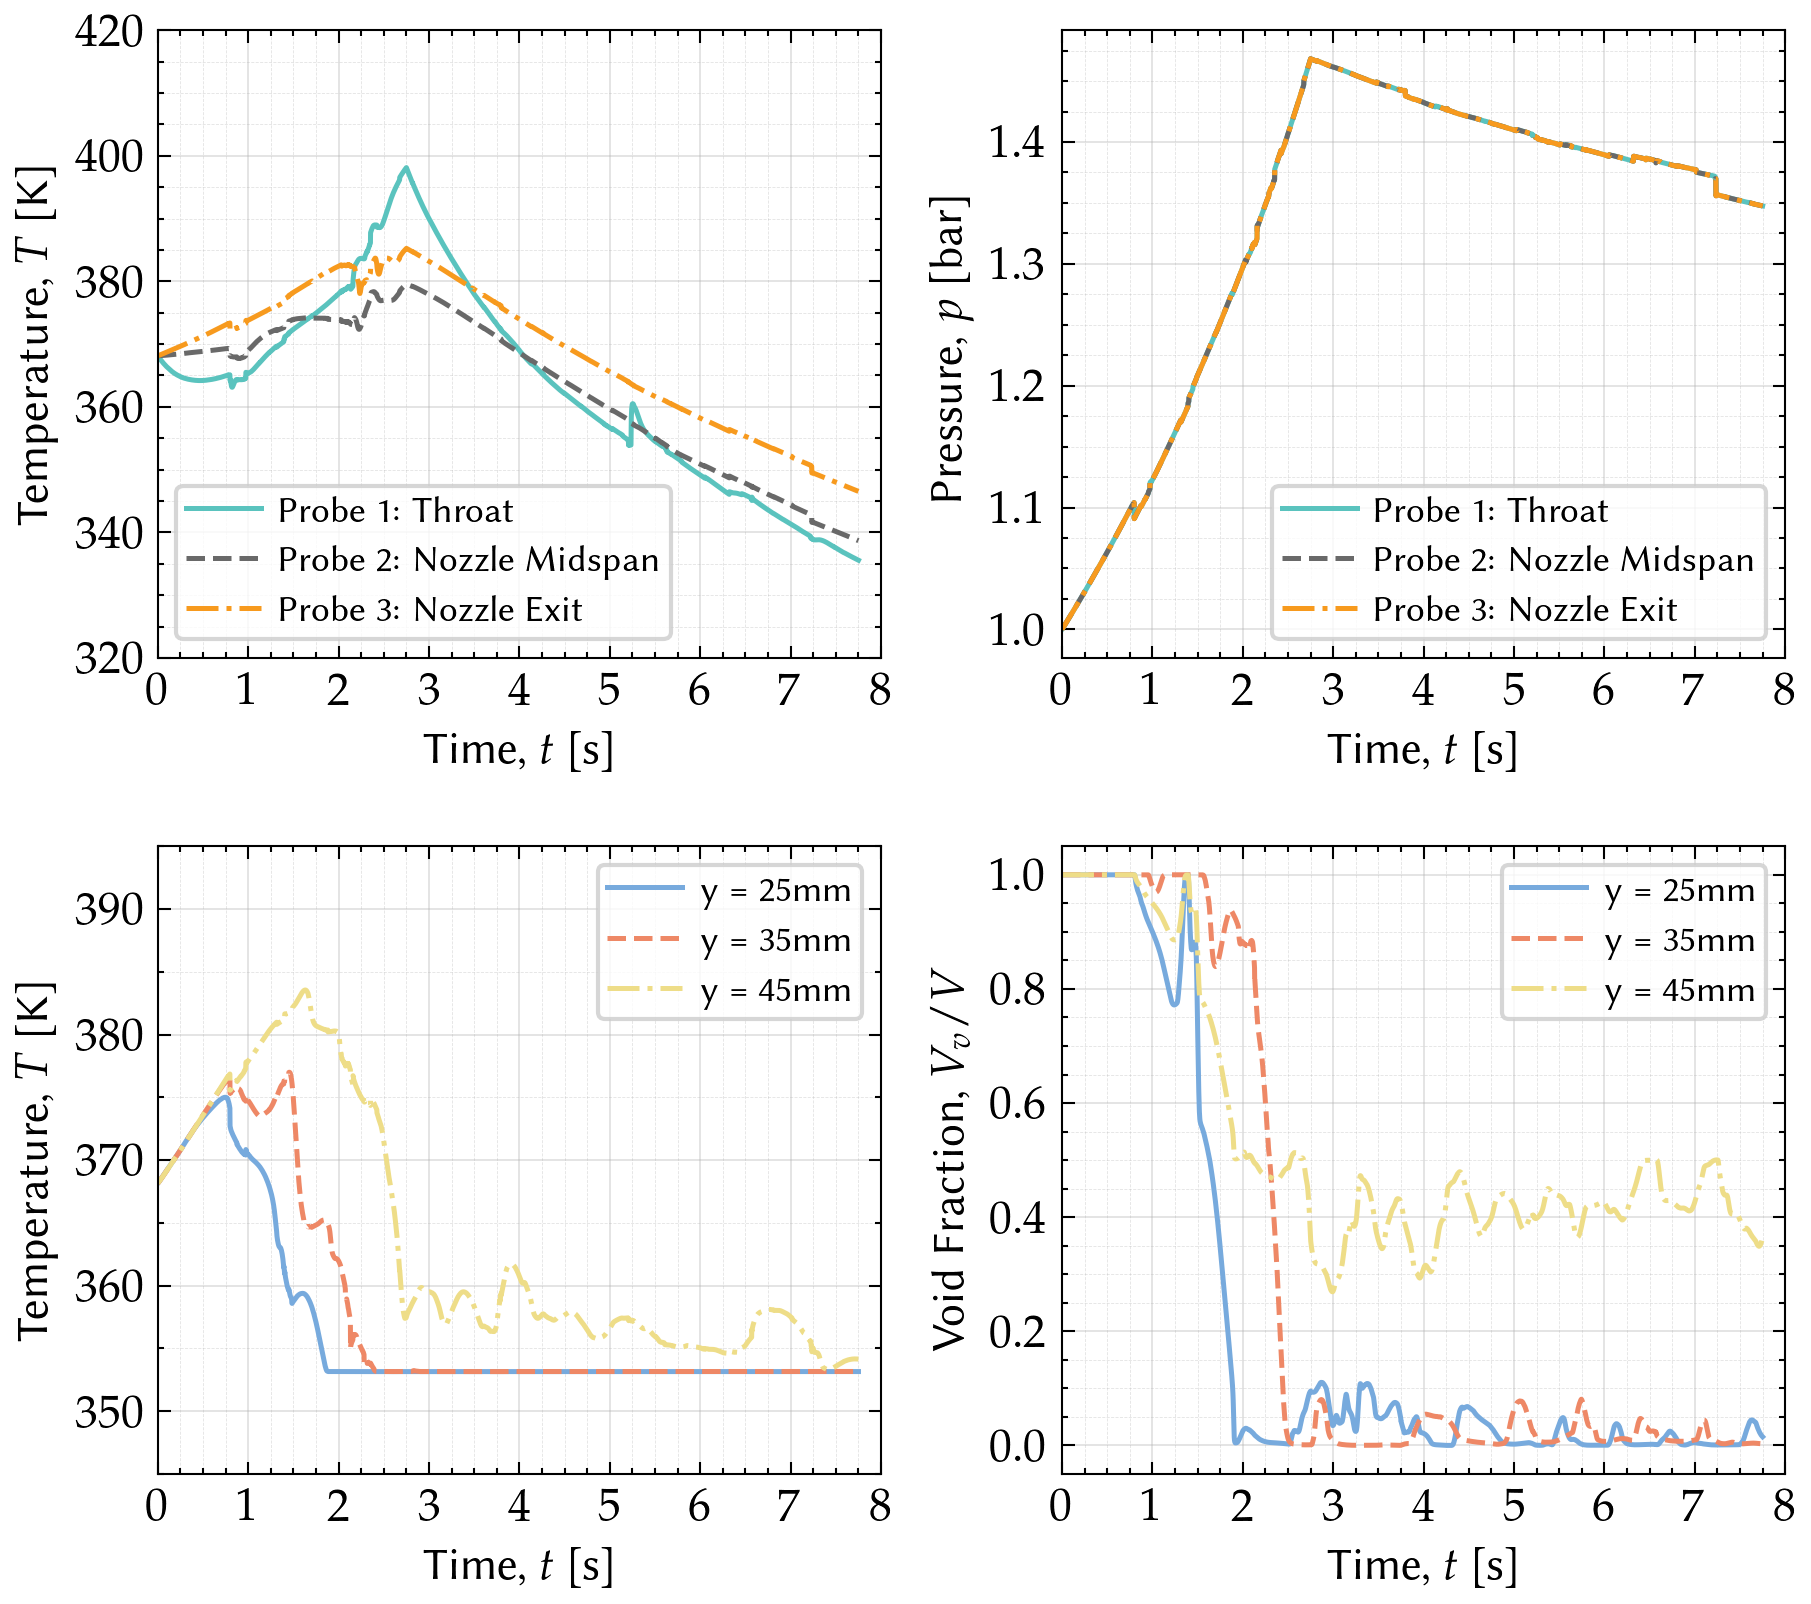

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from cycler import cycler
from itertools import cycle
import tol_colors as tc
import scienceplots
# Apply the 'science-modern' style globally
plt.style.use('science-modern')

# -------------------------------------------------------------------
# Load data
# -------------------------------------------------------------------
pt = pd.read_csv(r'D:\thesis\HARD_DATA\subprob1\probe_temps.csv')        # probe temperatures (K)
pp = pd.read_csv(r'D:\thesis\HARD_DATA\subprob1\probes_pressure.csv')    # probe pressures (Pa)
st = pd.read_csv(r'D:\thesis\HARD_DATA\subprob1\section_temps.csv')      # section plane temperatures (K)
sv = pd.read_csv(r'D:\thesis\HARD_DATA\subprob1\section_voidfrac.csv')   # section plane void fractions (-)

# Extract time arrays
t_pt = pt['Time'].values
t_pp = pp['Time'].values
t_st = st['Time'].values
t_sv = sv['Time'].values

# Extract data columns (skip 'Time')
pt_cols = [c for c in pt.columns if c != 'Time']
pp_cols = [c for c in pp.columns if c != 'Time']
st_cols = [c for c in st.columns if c != 'Time']
sv_cols = [c for c in sv.columns if c != 'Time']

# -------------------------------------------------------------------
# Create figure and axes
# -------------------------------------------------------------------
fig, axes = plt.subplots(
    nrows=2, ncols=2,
    figsize=(7, 6.25),
    dpi=300,
    gridspec_kw={'wspace': 0.25, 'hspace': 0.3}
)
(ax00, ax01), (ax10, ax11) = axes

# Assign color cycles: retro (top row), light (bottom row)
retro_colors = plt.style.library['retro']['axes.prop_cycle'].by_key()['color']
light_colors = plt.style.library['light']['axes.prop_cycle'].by_key()['color']
ax00.set_prop_cycle(cycler('color', retro_colors))
ax01.set_prop_cycle(cycler('color', retro_colors))
ax10.set_prop_cycle(cycler('color', light_colors))
ax11.set_prop_cycle(cycler('color', light_colors))

# Reusable cycles for markers & linestyles
def new_cycles():
    return cycle(['o', 's', '^', 'd', 'v', 'x']), cycle(['-', '--', '-.', ':'])

probe_names = [': Throat', ': Nozzle Midspan', ': Nozzle Exit']

# -------------------------------------------------------------------
# Top-left: Probe temperatures vs time
# -------------------------------------------------------------------
marks, lstyle = new_cycles()
for i, c in enumerate(pt_cols):
    if i == 0:
        continue
    label = f"Probe {i}" + (probe_names[i-1] if i-1 < len(probe_names) else "")
    ax00.plot(
        t_pt, pt[c].values,
        linestyle=next(lstyle),
        linewidth=1.2,
        #marker=next(marks),
        markerfacecolor='none',
        label=label
    )

ax00.set_xlabel(r"Time, $t$ [s]", fontsize=11)
ax00.set_ylabel(r"Temperature, $T$ [K]", fontsize=11)
ax00.set_ylim(320, 420)
ax00.yaxis.set_major_locator(ticker.MultipleLocator(20))
ax00.yaxis.set_minor_locator(ticker.MultipleLocator(5))
ax00.legend(loc="best", frameon=True, prop={'size': 9})
ax00.grid(which='minor', linestyle='--', linewidth=0.2, alpha=0.35)
ax00.grid(which='major', linestyle='-',  linewidth=0.4, alpha=0.4)
plt.setp(ax00.get_xticklabels(), fontsize=11)
plt.setp(ax00.get_yticklabels(), fontsize=11)

# -------------------------------------------------------------------
# Top-right: Probe pressures vs time
# -------------------------------------------------------------------
marks, lstyle = new_cycles()
for i, c in enumerate(pp_cols):
    if i == 0:
        continue
    label = f"Probe {i}" + (probe_names[i-1] if i-1 < len(probe_names) else "")
    pressure_in_bar = pp[c].values / 1e5
    ax01.plot(
        t_pp, pressure_in_bar,
        linestyle=next(lstyle),
        linewidth=1.2,
        #marker=next(marks),
        #markerfacecolor='none',
        label=label
    )

ax01.set_xlabel(r"Time, $t$ [s]", fontsize=11)
ax01.set_ylabel(r"Pressure, $p$ [bar]", fontsize=11)
ax01.yaxis.set_major_locator(ticker.MultipleLocator(0.1))
ax01.yaxis.set_minor_locator(ticker.MultipleLocator(0.025))
ax01.legend(loc="best", frameon=True, prop={'size': 9})
ax01.grid(which='minor', linestyle='--', linewidth=0.2, alpha=0.35)
ax01.grid(which='major', linestyle='-',  linewidth=0.4, alpha=0.4)
plt.setp(ax01.get_xticklabels(), fontsize=11)
plt.setp(ax01.get_yticklabels(), fontsize=11)

# -------------------------------------------------------------------
# Bottom-left: Section-plane temperatures vs time
# -------------------------------------------------------------------
marks, lstyle = new_cycles()
for c in st_cols:
    label = c.split(':')[0].strip()
    ax10.plot(
        t_st, st[c].values,
        linestyle=next(lstyle),
        linewidth=1.2,
        #marker=next(marks),
        #markerfacecolor='none',
        label=label
    )

ax10.set_xlabel(r"Time, $t$ [s]", fontsize=11)
ax10.set_ylabel(r"Temperature, $T$ [K]", fontsize=11)
ax10.set_ylim(345, 395)
ax10.yaxis.set_major_locator(ticker.MultipleLocator(10))
ax10.yaxis.set_minor_locator(ticker.MultipleLocator(5))
ax10.legend(loc="best", frameon=True, prop={'size': 9})
ax10.grid(which='minor', linestyle='--', linewidth=0.2, alpha=0.35)
ax10.grid(which='major', linestyle='-',  linewidth=0.4, alpha=0.4)
plt.setp(ax10.get_xticklabels(), fontsize=11)
plt.setp(ax10.get_yticklabels(), fontsize=11)

# -------------------------------------------------------------------
# Bottom-right: Section-plane void fractions vs time
# -------------------------------------------------------------------
marks, lstyle = new_cycles()
for c in sv_cols:
    label = c.split(':')[0].strip()
    ax11.plot(
        t_sv, sv[c].values,
        linestyle=next(lstyle),
        linewidth=1.2,
        #marker=next(marks),
        #markerfacecolor='none',
        label=label
    )

ax11.set_xlabel(r"Time, $t$ [s]", fontsize=11)
ax11.set_ylabel(r"Void Fraction, $V_{v}/V$", fontsize=11)
ax11.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax11.yaxis.set_minor_locator(ticker.MultipleLocator(0.05))
ax11.legend(loc="best", frameon=True, prop={'size': 9})
ax11.grid(which='minor', linestyle='--', linewidth=0.2, alpha=0.35)
ax11.grid(which='major', linestyle='-',  linewidth=0.4, alpha=0.4)
plt.setp(ax11.get_xticklabels(), fontsize=11)
plt.setp(ax11.get_yticklabels(), fontsize=11)

# -------------------------------------------------------------------
# Common x-axis for all plots
# -------------------------------------------------------------------
all_axes = [ax00, ax01, ax10, ax11]
for ax in all_axes:
    ax.set_xlim(0, 8)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.25))
    plt.setp(ax.get_xticklabels(), fontsize=11)

# Display the figure
plt.show()
